<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/C%C3%B3pia_de_EXERCICIO_PERCEPTRON_PREDI%C3%87%C3%83O_CACHORRO_GATO_CRIADO_POR_MIM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INICIANDO TREINAMENTO DO PERCEPTRON
Taxa de aprendizado: 0.1
Número de épocas: 50
Pesos iniciais: w1=-0.000374, w2=0.002243, bias=-0.008686

ÉPOCA 1
Cachorro 1      | Peso: 25kg | Altura: 60cm | Soma:  0.1165 | Pred: Cachorro | Real: Cachorro | ✓ CORRETO

Cachorro 2      | Peso: 20kg | Altura: 55cm | Soma:  0.1072 | Pred: Cachorro | Real: Cachorro | ✓ CORRETO

Cachorro 3      | Peso: 30kg | Altura: 65cm | Soma:  0.1259 | Pred: Cachorro | Real: Cachorro | ✓ CORRETO

Gato 1          | Peso:  5kg | Altura: 25cm | Soma:  0.0455 | Pred: Cachorro | Real: Gato     | ✗ ERROU
  └─ Ajustando pesos...
     w1: -0.000374 → -0.500374
     w2: 0.002243 → -2.497757
     bias: -0.008686 → -0.108686

Gato 2          | Peso:  4kg | Altura: 20cm | Soma: -52.0653 | Pred: Gato     | Real: Gato     | ✓ CORRETO

Gato 3          | Peso:  6kg | Altura: 28cm | Soma: -73.0481 | Pred: Gato     | Real: Gato     | ✓ CORRETO

Total de erros na Época 1: 1

ÉPOCA 2
Cachorro 1      | Peso: 25kg | Altura: 60cm | Soma: -

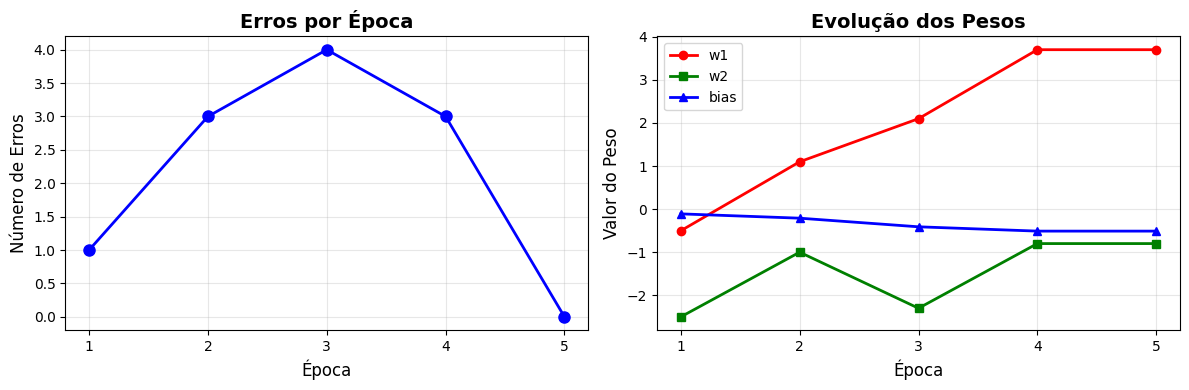

In [ ]:
# Importa a biblioteca NumPy para operações matemáticas
import numpy as np

# Importa a biblioteca Matplotlib para criar gráficos
import matplotlib.pyplot as plt

# Define a classe PerceptronTreinador que encapsula toda a lógica do Perceptron
class PerceptronTreinador:

    # Método construtor que inicializa os parâmetros do Perceptron
    def __init__(self, taxa_aprendizado=0.1, epocas=100):

        # Armazena a taxa de aprendizado (controla o tamanho dos ajustes de peso)
        self.taxa_aprendizado = taxa_aprendizado

        # Armazena o número de épocas (quantas vezes vai passar pelos dados)
        self.epocas = epocas

        # Inicializa o peso 1 com um valor aleatório muito pequeno (para a primeira característica)
        self.w1 = np.random.randn() * 0.01

        # Inicializa o peso 2 com um valor aleatório muito pequeno (para a segunda característica)
        self.w2 = np.random.randn() * 0.01

        # Inicializa o bias com um valor aleatório muito pequeno (ajuste geral da rede)
        self.bias = np.random.randn() * 0.01

        # Cria uma lista vazia para armazenar o número de erros em cada época (para o gráfico)
        self.historico_erros = []

        # Cria uma lista vazia para armazenar os valores dos pesos em cada época (para visualizar evolução)
        self.historico_pesos = []

    # Define a função de ativação do Perceptron
    def funcao_ativacao(self, soma):

        # Docstring explicando o que a função faz
        """Função degrau: 1 se soma >= 0, senão 0"""
        # Retorna 1 se a soma for maior ou igual a 0, senão retorna 0

        return 1 if soma >= 0 else 0

    # Define a função que faz uma predição para um animal
    def prever(self, peso, altura):

        # Docstring explicando o que a função faz
        """Faz uma predição para um animal"""

        # Calcula a soma ponderada: (peso * w1) + (altura * w2) + bias
        soma = self.w1 * peso + self.w2 * altura + self.bias

        # Aplica a função de ativação à soma para obter a predição (0 ou 1)
        predicao = self.funcao_ativacao(soma)

        # Retorna tanto a predição quanto a soma (para visualização)
        return predicao, soma

    # Define a função que treina o Perceptron
    def treinar(self, dados_treino):

        # Docstring explicando o que a função faz
        """
        Treina o perceptron
        dados_treino: lista de dicionários com 'peso', 'altura' e 'classe'
        """

        # Imprime uma linha de separação para melhor visualização
        print("=" * 70)

        # Imprime o título do treinamento
        print("INICIANDO TREINAMENTO DO PERCEPTRON")

        # Imprime outra linha de separação
        print("=" * 70)

        # Imprime a taxa de aprendizado que está sendo usada
        print(f"Taxa de aprendizado: {self.taxa_aprendizado}")

        # Imprime o número de épocas que serão executadas
        print(f"Número de épocas: {self.epocas}")

        # Imprime os valores iniciais dos pesos e bias com 6 casas decimais
        print(f"Pesos iniciais: w1={self.w1:.6f}, w2={self.w2:.6f}, bias={self.bias:.6f}")

        # Imprime uma linha em branco para separação
        print()

        # Inicia um loop que vai de 0 até o número de épocas
        for epoca in range(self.epocas):

            # Inicializa um contador de erros para esta época em 0
            erros_nesta_epoca = 0

            # Imprime uma linha de separação
            print(f"{'=' * 70}")

            # Imprime qual época está sendo executada (época + 1 porque começa em 0)
            print(f"ÉPOCA {epoca + 1}")

            # Imprime outra linha de separação
            print(f"{'=' * 70}")

            # Inicia um loop que percorre cada animal nos dados de treinamento
            for i, animal in enumerate(dados_treino):

                # Extrai o peso do animal do dicionário
                peso = animal['peso']

                # Extrai a altura do animal do dicionário
                altura = animal['altura']

                # Extrai a classe real do animal (0 para gato, 1 para cachorro)
                classe_real = animal['classe']

                # Extrai o nome do animal do dicionário
                nome = animal['nome']

                # Chama a função prever para obter a predição e a soma
                predicao, soma = self.prever(peso, altura)

                # Calcula o erro subtraindo a predição da classe real
                erro = classe_real - predicao

                # Cria uma string com o nome da classe predita (1 = Cachorro, 0 = Gato)
                classe_pred = "Cachorro" if predicao == 1 else "Gato"

                # Cria uma string com o nome da classe real (1 = Cachorro, 0 = Gato)
                classe_real_nome = "Cachorro" if classe_real == 1 else "Gato"

                # Define o status como CORRETO se erro é 0, senão ERROU
                status = "✓ CORRETO" if erro == 0 else "✗ ERROU"

                # Imprime uma linha com todas as informações do animal e sua predição
                print(f"{nome:15} | Peso: {peso:2}kg | Altura: {altura:2}cm | "

                      f"Soma: {soma:7.4f} | Pred: {classe_pred:8} | "

                      f"Real: {classe_real_nome:8} | {status}")

                # Verifica se houve erro (erro diferente de 0)
                if erro != 0:

                    # Imprime uma mensagem indicando que os pesos serão ajustados
                    print(f"  └─ Ajustando pesos...")

                    # Armazena o valor antigo de w1 para mostrar a mudança
                    w1_antigo = self.w1

                    # Armazena o valor antigo de w2 para mostrar a mudança
                    w2_antigo = self.w2

                    # Armazena o valor antigo de bias para mostrar a mudança
                    bias_antigo = self.bias

                    # Atualiza w1 usando a regra do Perceptron: w1 = w1 + taxa * erro * peso
                    self.w1 = self.w1 + self.taxa_aprendizado * erro * peso

                    # Atualiza w2 usando a regra do Perceptron: w2 = w2 + taxa * erro * altura
                    self.w2 = self.w2 + self.taxa_aprendizado * erro * altura

                    # Atualiza bias usando a regra do Perceptron: bias = bias + taxa * erro
                    self.bias = self.bias + self.taxa_aprendizado * erro

                    # Imprime o valor antigo e novo de w1 com 6 casas decimais
                    print(f"     w1: {w1_antigo:8.6f} → {self.w1:8.6f}")

                    # Imprime o valor antigo e novo de w2 com 6 casas decimais
                    print(f"     w2: {w2_antigo:8.6f} → {self.w2:8.6f}")

                    # Imprime o valor antigo e novo de bias com 6 casas decimais
                    print(f"     bias: {bias_antigo:8.6f} → {self.bias:8.6f}")

                    # Incrementa o contador de erros desta época
                    erros_nesta_epoca += 1

                # Imprime uma linha em branco para separação entre animais
                print()

            # Adiciona o número de erros desta época à lista de histórico
            self.historico_erros.append(erros_nesta_epoca)

            # Adiciona um dicionário com os pesos atuais à lista de histórico
            self.historico_pesos.append({

                'w1': self.w1,
                'w2': self.w2,
                'bias': self.bias
            })

            # Imprime o total de erros que ocorreram nesta época
            print(f"Total de erros na Época {epoca + 1}: {erros_nesta_epoca}")

            # Imprime uma linha em branco para separação entre épocas
            print()

            # Verifica se o Perceptron convergiu (zero erros)
            if erros_nesta_epoca == 0:

                # Imprime uma linha de separação
                print("=" * 70)

                # Imprime uma mensagem de sucesso indicando em qual época convergiu
                print(f"✓ PERCEPTRON CONVERGIU NA ÉPOCA {epoca + 1}!")

                # Imprime outra linha de separação
                print("=" * 70)

                # Imprime uma linha em branco
                print()

                # Sai do loop de épocas (para de treinar)
                break

        # Imprime uma linha de separação
        print("=" * 70)

        # Imprime uma mensagem indicando que o treinamento terminou
        print("TREINAMENTO FINALIZADO")

        # Imprime outra linha de separação
        print("=" * 70)

        # Imprime os valores finais dos pesos e bias com 6 casas decimais
        print(f"Pesos finais: w1={self.w1:.6f}, w2={self.w2:.6f}, bias={self.bias:.6f}")

        # Imprime uma linha em branco
        print()

    # Define a função que testa o Perceptron em dados novos
    def testar(self, dados_teste):

        # Docstring explicando o que a função faz
        """Testa o perceptron em novos dados"""

        # Imprime uma linha de separação
        print("=" * 70)

        # Imprime o título da seção de testes
        print("TESTANDO O PERCEPTRON")

        # Imprime outra linha de separação
        print("=" * 70)

        # Inicializa um contador de acertos em 0
        acertos = 0

        # Inicia um loop que percorre cada animal nos dados de teste
        for animal in dados_teste:

            # Extrai o peso do animal do dicionário
            peso = animal['peso']

            # Extrai a altura do animal do dicionário
            altura = animal['altura']

            # Extrai a classe real do animal (0 para gato, 1 para cachorro)
            classe_real = animal['classe']

            # Extrai o nome do animal do dicionário
            nome = animal['nome']

            # Chama a função prever para obter a predição e a soma
            predicao, soma = self.prever(peso, altura)

            # Cria uma string com o nome da classe predita (1 = Cachorro, 0 = Gato)
            classe_pred = "Cachorro" if predicao == 1 else "Gato"

            # Cria uma string com o nome da classe real (1 = Cachorro, 0 = Gato)
            classe_real_nome = "Cachorro" if classe_real == 1 else "Gato"

            # Verifica se a predição é igual à classe real
            if predicao == classe_real:

                # Define o status como CORRETO
                status = "✓ CORRETO"

                # Incrementa o contador de acertos
                acertos += 1
            else:
                # Define o status como ERROU
                status = "✗ ERROU"

            # Imprime uma linha com todas as informações do animal e sua predição
            print(f"{nome:15} | Peso: {peso:2}kg | Altura: {altura:2}cm | "

                  f"Soma: {soma:7.4f} | Pred: {classe_pred:8} | "

                  f"Real: {classe_real_nome:8} | {status}")

        # Imprime uma linha em branco
        print()

        # Imprime o número de acertos e a porcentagem de acerto
        print(f"Acertos: {acertos}/{len(dados_teste)} ({acertos/len(dados_teste)*100:.1f}%)")

        # Imprime uma linha em branco
        print()

    # Define a função que cria gráficos do treinamento
    def visualizar_treinamento(self):

        # Docstring explicando o que a função faz
        """Cria gráficos do treinamento"""

        # Cria uma figura com tamanho 12 de largura e 4 de altura
        plt.figure(figsize=(12, 4))

        # Cria o primeiro subplot (1 linha, 2 colunas, posição 1)
        plt.subplot(1, 2, 1)

        # Plota uma linha com os erros de cada época (range começa em 1 para melhor visualização)
        plt.plot(range(1, len(self.historico_erros) + 1),

                 self.historico_erros, 'b-o', linewidth=2, markersize=8)

        # Define o rótulo do eixo X
        plt.xlabel('Época', fontsize=12)

        # Define o rótulo do eixo Y
        plt.ylabel('Número de Erros', fontsize=12)

        # Define o título do gráfico
        plt.title('Erros por Época', fontsize=14, fontweight='bold')

        # Ativa a grade do gráfico com transparência
        plt.grid(True, alpha=0.3)

        # Define os valores do eixo X (mostra todas as épocas)
        plt.xticks(range(1, len(self.historico_erros) + 1))

        # Cria o segundo subplot (1 linha, 2 colunas, posição 2)
        plt.subplot(1, 2, 2)

        # Extrai todos os valores de w1 do histórico de pesos
        w1_valores = [p['w1'] for p in self.historico_pesos]

        # Extrai todos os valores de w2 do histórico de pesos
        w2_valores = [p['w2'] for p in self.historico_pesos]

        # Extrai todos os valores de bias do histórico de pesos
        bias_valores = [p['bias'] for p in self.historico_pesos]

        # Plota a evolução de w1 com cor vermelha e marcadores em círculo
        plt.plot(range(1, len(w1_valores) + 1), w1_valores, 'r-o', label='w1', linewidth=2)

        # Plota a evolução de w2 com cor verde e marcadores em quadrado
        plt.plot(range(1, len(w2_valores) + 1), w2_valores, 'g-s', label='w2', linewidth=2)

        # Plota a evolução de bias com cor azul e marcadores em triângulo
        plt.plot(range(1, len(bias_valores) + 1), bias_valores, 'b-^', label='bias', linewidth=2)

        # Define o rótulo do eixo X
        plt.xlabel('Época', fontsize=12)

        # Define o rótulo do eixo Y
        plt.ylabel('Valor do Peso', fontsize=12)

        # Define o título do gráfico
        plt.title('Evolução dos Pesos', fontsize=14, fontweight='bold')

        # Adiciona uma legenda ao gráfico
        plt.legend(fontsize=10)

        # Ativa a grade do gráfico com transparência
        plt.grid(True, alpha=0.3)

        # Define os valores do eixo X (mostra todas as épocas)
        plt.xticks(range(1, len(w1_valores) + 1))

        # Ajusta o espaçamento entre os subplots
        plt.tight_layout()
        # Exibe os gráficos na tela
        plt.show()


# ============================================================================
# DADOS DE TREINAMENTO
# ============================================================================

# Cria uma lista com os dados de treinamento (6 animais: 3 cachorros e 3 gatos)
dados_treino = [

    # Primeiro cachorro: peso 25kg, altura 60cm, classe 1 (Cachorro)
    {'nome': 'Cachorro 1', 'peso': 25, 'altura': 60, 'classe': 1},

    # Segundo cachorro: peso 20kg, altura 55cm, classe 1 (Cachorro)
    {'nome': 'Cachorro 2', 'peso': 20, 'altura': 55, 'classe': 1},

    # Terceiro cachorro: peso 30kg, altura 65cm, classe 1 (Cachorro)
    {'nome': 'Cachorro 3', 'peso': 30, 'altura': 65, 'classe': 1},

    # Primeiro gato: peso 5kg, altura 25cm, classe 0 (Gato)
    {'nome': 'Gato 1', 'peso': 5, 'altura': 25, 'classe': 0},

    # Segundo gato: peso 4kg, altura 20cm, classe 0 (Gato)
    {'nome': 'Gato 2', 'peso': 4, 'altura': 20, 'classe': 0},

    # Terceiro gato: peso 6kg, altura 28cm, classe 0 (Gato)
    {'nome': 'Gato 3', 'peso': 6, 'altura': 28, 'classe': 0},
]

# ============================================================================
# DADOS DE TESTE (novos animais que o perceptron nunca viu)
# ============================================================================

# Cria uma lista com os dados de teste (3 animais novos)
dados_teste = [
    # Novo animal 1: peso 22kg, altura 58cm, classe 1 (Cachorro)
    {'nome': 'Novo Animal 1', 'peso': 22, 'altura': 58, 'classe': 1},

    # Novo animal 2: peso 5.5kg, altura 26cm, classe 0 (Gato)
    {'nome': 'Novo Animal 2', 'peso': 5.5, 'altura': 26, 'classe': 0},

    # Novo animal 3: peso 28kg, altura 62cm, classe 1 (Cachorro)
    {'nome': 'Novo Animal 3', 'peso': 28, 'altura': 62, 'classe': 1},
]

# ============================================================================
# EXECUTAR O TREINAMENTO
# ============================================================================

# Cria uma instância da classe PerceptronTreinador com taxa de aprendizado 0.1 e 50 épocas
perceptron = PerceptronTreinador(taxa_aprendizado=0.1, epocas=50)

# Chama a função treinar passando os dados de treinamento
perceptron.treinar(dados_treino)

# Chama a função testar passando os dados de teste
perceptron.testar(dados_teste)

# Chama a função visualizar_treinamento para exibir os gráficos
perceptron.visualizar_treinamento()